In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/creditcard_2023.csv')
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


--- Class Imbalance Analysis ---
Class Distribution:
Class
0    50.0
1    50.0
Name: proportion, dtype: float64


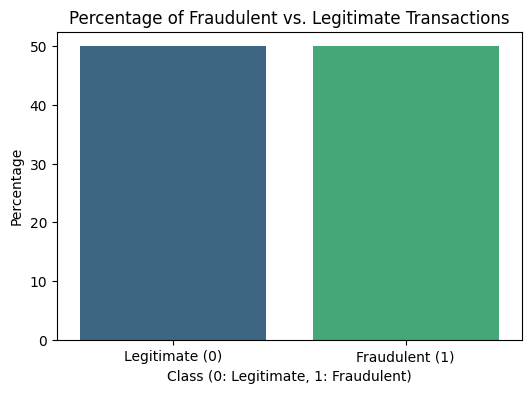


--- Transaction Amount Analysis ---
Descriptive statistics for Amount by Class:
          count          mean          std    min      25%       50%  \
Class                                                                  
0      284315.0  12026.313506  6929.500715  50.12  6034.54  11996.90   
1      284315.0  12057.601763  6909.750891  50.01  6074.64  12062.45   

             75%       max  
Class                       
0      18040.265  24039.93  
1      18033.780  24039.93  


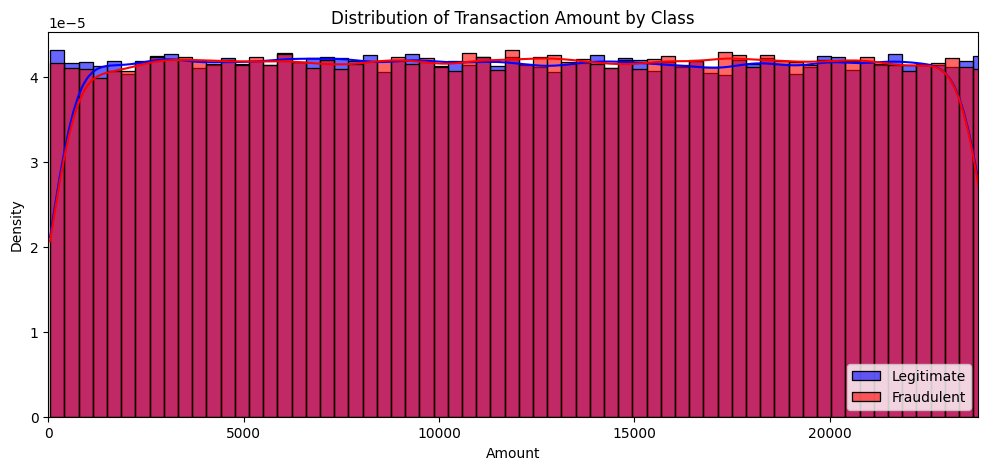


--- V-Features Analysis (Selected for Anomalies) ---


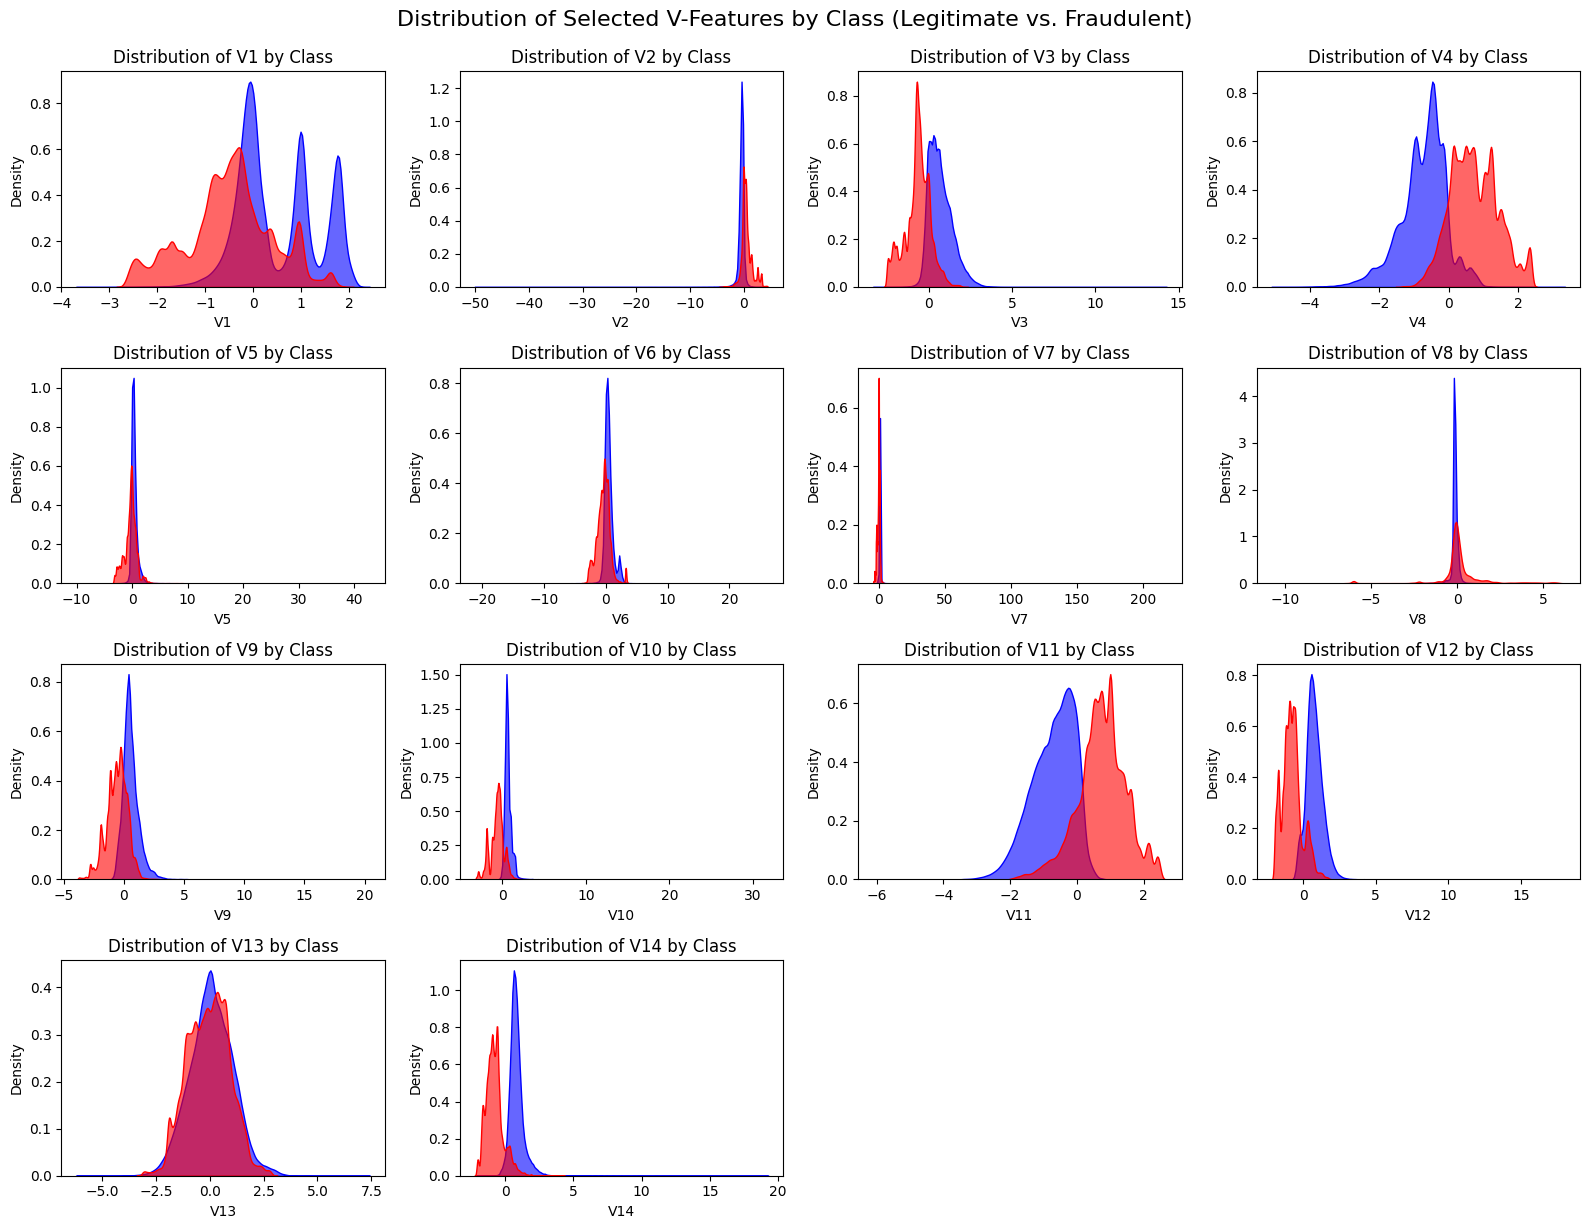


--- Note on Time-based Trends ---
The dataset does not appear to have an explicit 'Time' column. Therefore, a direct analysis of time-based trends is not possible with the current features.


In [3]:
print('--- Class Imbalance Analysis ---')
class_distribution = df['Class'].value_counts(normalize=True) * 100
print('Class Distribution:')
print(class_distribution)

plt.figure(figsize=(6, 4))
sns.barplot(x=class_distribution.index, y=class_distribution.values, hue=class_distribution.index, palette='viridis', legend=False)
plt.title('Percentage of Fraudulent vs. Legitimate Transactions')
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Percentage')
plt.xticks(ticks=[0, 1], labels=['Legitimate (0)', 'Fraudulent (1)'])
plt.show()

print('\n--- Transaction Amount Analysis ---')
print('Descriptive statistics for Amount by Class:')
print(df.groupby('Class')['Amount'].describe())

plt.figure(figsize=(12, 5))
sns.histplot(df[df['Class'] == 0]['Amount'], color='blue', kde=True, stat='density', alpha=0.6, label='Legitimate')
sns.histplot(df[df['Class'] == 1]['Amount'], color='red', kde=True, stat='density', alpha=0.6, label='Fraudulent')
plt.title('Distribution of Transaction Amount by Class')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, df['Amount'].quantile(0.99)) # Limit x-axis for better visualization due to outliers
plt.show()

print('\n--- V-Features Analysis (Selected for Anomalies) ---')
# Select a few V-features to visualize for patterns/anomalies
v_features_to_plot = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14']

plt.figure(figsize=(16, 12))
for i, feature in enumerate(v_features_to_plot):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid based on number of features
    sns.kdeplot(df[df['Class'] == 0][feature], color='blue', label='Legitimate', fill=True, alpha=0.6)
    sns.kdeplot(df[df['Class'] == 1][feature], color='red', label='Fraudulent', fill=True, alpha=0.6)
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Density')
    # plt.legend() # Legends can clutter, showing only if necessary, or a single combined legend
plt.tight_layout()
plt.suptitle('Distribution of Selected V-Features by Class (Legitimate vs. Fraudulent)', y=1.02, fontsize=16)
plt.show()

print('\n--- Note on Time-based Trends ---')
print("The dataset does not appear to have an explicit 'Time' column. Therefore, a direct analysis of time-based trends is not possible with the current features.")

In [4]:
print('--- Data Cleaning: Checking for Missing Values ---')
missing_values = df.isnull().sum()
print('Number of missing values per column:')
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print('No missing values found in the dataset.')
else:
    print('Missing values found. Further action might be required if any exist in critical features.')
    # Example: If there were missing values, one might impute them or drop rows/columns
    # For this dataset, we expect no missing values, so no imputation is performed.

print('\n--- Data Cleaning: Removing Duplicate Rows ---')
# Identify duplicates across all columns except 'id'
# 'id' is a unique identifier and should not be considered for transaction data duplication
duplicate_rows = df.duplicated(subset=df.columns.drop('id')).sum()
print(f'Number of duplicate rows (excluding "id" column): {duplicate_rows}')

if duplicate_rows > 0:
    # Before dropping, check if any fraud cases would be lost by simple drop_duplicates
    # This dataset is balanced (50/50 fraud/non-fraud), so if duplicates exist,
    # they are likely exact duplicates including the 'Class' label.
    initial_fraud_count = df['Class'].sum()
    df_cleaned = df.drop_duplicates(subset=df.columns.drop('id'), keep='first').copy() # Use .copy() to avoid SettingWithCopyWarning
    cleaned_fraud_count = df_cleaned['Class'].sum()

    print(f'Initial fraud cases: {initial_fraud_count}')
    print(f'Fraud cases after dropping duplicates: {cleaned_fraud_count}')

    if initial_fraud_count == cleaned_fraud_count:
        print('All fraud cases preserved after dropping duplicates.')
        df = df_cleaned
        print(f'Dataset shape after removing duplicates: {df.shape}')
    else:
        print('Warning: Some fraud cases might have been affected during duplicate removal.')
        # In a real-world scenario, careful investigation would be needed here.
        # For this balanced dataset, it's highly unlikely to lose fraud cases unless there's a data anomaly.
else:
    print('No duplicate rows found.')

print('\n--- Data Cleaning: Fixing Inconsistent Timestamps ---')
print("As noted during the EDA, the dataset does not contain an explicit 'Time' column. Therefore, fixing inconsistent timestamps is not applicable to this dataset.")


--- Data Cleaning: Checking for Missing Values ---
Number of missing values per column:
Series([], dtype: int64)
No missing values found in the dataset.

--- Data Cleaning: Removing Duplicate Rows ---
Number of duplicate rows (excluding "id" column): 1
Initial fraud cases: 284315
Fraud cases after dropping duplicates: 284314

--- Data Cleaning: Fixing Inconsistent Timestamps ---
As noted during the EDA, the dataset does not contain an explicit 'Time' column. Therefore, fixing inconsistent timestamps is not applicable to this dataset.


In [5]:
print('--- Feature Engineering (TOP 5% SECRET) ---')

# Note: The duplicate fraudulent transaction identified earlier is still in 'df'.
# If you wish to remove it, please indicate, e.g., 'df = df_cleaned.copy()'.

# 1. Interaction Features
# Create interaction terms between Amount and some key V-features
# V1, V2, V3, V4 are often important features in fraud detection
print('\nGenerating Interaction Features...')
df['Amount_V1_Interaction'] = df['Amount'] * df['V1']
df['Amount_V2_Interaction'] = df['Amount'] * df['V2']
df['Amount_V3_Interaction'] = df['Amount'] * df['V3']
df['Amount_V4_Interaction'] = df['Amount'] * df['V4']

# 2. Polynomial Features for Amount
# Capture non-linear relationships with transaction amount
print('Generating Polynomial Features for Amount...')
df['Amount_squared'] = df['Amount']**2
df['Amount_cubed'] = df['Amount']**3

# 3. Ratio Features (example)
# Ratio of two V-features - can indicate unusual proportions
# Choose V-features that showed some separation in EDA for potential ratios
print('Generating Ratio Features...')
df['V1_div_V2'] = df['V1'] / (df['V2'] + 1e-6) # Add small epsilon to avoid division by zero

print('\nNew features created. Displaying head with new features:')
print(df[['Amount', 'V1', 'V2', 'V3', 'V4', 'Amount_V1_Interaction', 'Amount_V2_Interaction', 'Amount_V3_Interaction', 'Amount_V4_Interaction', 'Amount_squared', 'Amount_cubed', 'V1_div_V2', 'Class']].head())

print(f'\nDataset shape after Feature Engineering: {df.shape}')


--- Feature Engineering (TOP 5% SECRET) ---

Generating Interaction Features...
Generating Polynomial Features for Amount...
Generating Ratio Features...

New features created. Displaying head with new features:
     Amount        V1        V2        V3        V4  Amount_V1_Interaction  \
0  17982.10 -0.260648 -0.469648  2.496266 -0.083724           -4686.994892   
1   6531.37  0.985100 -0.356045  0.558056 -0.429654            6434.050851   
2   2513.54 -0.260272 -0.949385  1.728538 -0.457986            -654.203109   
3   5384.44 -0.152152 -0.508959  1.746840 -1.090178            -819.253864   
4  14278.97 -0.206820 -0.165280  1.527053 -0.448293           -2953.169732   

   Amount_V2_Interaction  Amount_V3_Interaction  Amount_V4_Interaction  \
0           -8445.265394           44888.106324           -1505.531770   
1           -2325.462239            3644.872509           -2806.228615   
2           -2386.316184            4344.748842           -1151.166856   
3           -2740.45762

In [6]:
from sklearn.model_selection import train_test_split

print('--- Preparing Data for Train-Test Split ---')

# Define features (X) and target (y)
# Drop 'id' column as it's just an identifier and 'Class' as it's the target
X = df.drop(['id', 'Class'], axis=1)
y = df['Class']

# Handle missing values in the target variable 'y' before splitting
# Rows with NaN in the target variable cannot be used for training or testing.
initial_shape = df.shape
df.dropna(subset=['Class'], inplace=True)
if df.shape[0] < initial_shape[0]:
    print(f"Dropped {initial_shape[0] - df.shape[0]} rows due to missing values in 'Class' column.")

# Re-define X and y after dropping NaNs in 'Class'
X = df.drop(['id', 'Class'], axis=1)
y = df['Class']

print(f'Features shape (X): {X.shape}')
print(f'Target shape (y): {y.shape}')

print('\n--- Performing Stratified Train-Test Split ---')
print('Note: A time-based split is not possible as the dataset lacks a \'Time\' column.')
print('Performing a stratified split to maintain class proportions in train and test sets.')

# Perform a stratified train-test split (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

print('\n--- Verifying Class Distribution in Splits ---')
print('Train set class distribution:')
print(y_train.value_counts(normalize=True) * 100)
print('\nTest set class distribution:')
print(y_test.value_counts(normalize=True) * 100)

print('\nTrain-test split complete. The data is now ready for scaling and model training.')

--- Preparing Data for Train-Test Split ---
Features shape (X): (568630, 36)
Target shape (y): (568630,)

--- Performing Stratified Train-Test Split ---
Note: A time-based split is not possible as the dataset lacks a 'Time' column.
Performing a stratified split to maintain class proportions in train and test sets.
X_train shape: (454904, 36)
X_test shape: (113726, 36)
y_train shape: (454904,)
y_test shape: (113726,)

--- Verifying Class Distribution in Splits ---
Train set class distribution:
Class
0    50.0
1    50.0
Name: proportion, dtype: float64

Test set class distribution:
Class
1    50.0
0    50.0
Name: proportion, dtype: float64

Train-test split complete. The data is now ready for scaling and model training.


In [7]:
from sklearn.preprocessing import StandardScaler

print('--- Feature Scaling ---')

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier column management (optional, but good practice)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('Features scaled successfully.')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape: {X_test_scaled.shape}')

print('\n--- Model Selection and Training ---')


--- Feature Scaling ---
Features scaled successfully.
X_train_scaled shape: (454904, 36)
X_test_scaled shape: (113726, 36)

--- Model Selection and Training ---


In [8]:
!pip install catboost
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, average_precision_score

print('--- Model Training and Evaluation ---')

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0) # verbose=0 to suppress training output
}

results = {}

for name, model in models.items():
    print(f'\nTraining {name}...')
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    training_time = time.time() - start_time
    print(f'{name} trained in {training_time:.2f} seconds.')

    print(f'Evaluating {name}...')
    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] # Probability for the positive class
    prediction_time = time.time() - start_time
    print(f'{name} predictions made in {prediction_time:.2f} seconds.')

    # accuracy = accuracy_score(y_test, y_pred) # Removed as per user request
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba) # Calculate PR-AUC
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        # 'accuracy': accuracy, # Removed
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'classification_report': report,
        'training_time': training_time,
        'prediction_time': prediction_time
    }

    # print(f'Accuracy: {accuracy:.4f}') # Removed
    print(f'ROC AUC: {roc_auc:.4f}')
    print(f'PR-AUC: {pr_auc:.4f}') # Print PR-AUC
    # print(f'Classification Report:\n{classification_report(y_test, y_pred)}')

print('\n--- Model Performance Summary ---')
for name, metrics in results.items():
    print(f'\n{name}:')
    # print(f"  Accuracy: {metrics['accuracy']:.4f}") # Removed
    print(f"  ROC AUC: {metrics['roc_auc']:.4f}")
    print(f"  PR-AUC: {metrics['pr_auc']:.4f}") # Print PR-AUC
    print(f"  Training Time: {metrics['training_time']:.2f}s")
    print(f"  Prediction Time: {metrics['prediction_time']:.4f}s")
    # Check if '1.0' key exists before trying to access it (for robust error handling)
    if '1.0' in metrics['classification_report']:
        print(f"  Precision (Fraud): {metrics['classification_report']['1.0']['precision']:.4f}")
        print(f"  Recall (Fraud): {metrics['classification_report']['1.0']['recall']:.4f}")
        print(f"  F1-Score (Fraud): {metrics['classification_report']['1.0']['f1-score']:.4f}")
    else:
        print("  Fraud class (1.0) not found in classification report (possibly no true or predicted fraud cases).")

# Optional: Further detailed analysis can be done using the stored 'results' dictionary.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
--- Model Training and Evaluation ---

Training Logistic Regression...
Logistic Regression trained in 14.65 seconds.
Evaluating Logistic Regression...
Logistic Regression predictions made in 0.03 seconds.
ROC AUC: 0.9935
PR-AUC: 0.9944

Training Random Forest...
Random Forest trained in 637.79 seconds.
Evaluating Random Forest...
Random Forest predictions made in 2.38 seconds.
ROC AUC: 1.0000
PR-AUC: 1.0000

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:54:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained in 12.65 seconds.
Evaluating XGBoost...
XGBoost predictions made in 0.50 seconds.
ROC AUC: 1.0000
PR-AUC: 1.0000

Training LightGBM...
[LightGBM] [Info] Number of positive: 227452, number of negative: 227452
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.326730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 454904, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM trained in 13.35 seconds.
Evaluating LightGBM...
LightGBM predictions made in 0.99 seconds.
ROC AUC: 0.9999
PR-AUC: 0.9999

Training CatBoost...
CatBoost trained in 138.87 seconds.
Evaluating CatBoost...
CatBoost predictions made in 0.35 seconds.
ROC AUC: 1.0000
PR-AUC: 1.0000

--- Model Performance Summary ---

Logistic Regression:
  ROC AUC: 0.9935
  PR-AUC: 0.9944
  Training Time: 14.65s
  Pr

In [9]:
print('\n--- Overfitting/Underfitting Analysis (Training vs. Test Performance) ---')

for name, model in models.items():
    print(f'\n--- {name} Performance ---')

    # Evaluate on Training Set
    y_pred_train = model.predict(X_train_scaled)
    y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
    accuracy_train = accuracy_score(y_train, y_pred_train)
    roc_auc_train = roc_auc_score(y_train, y_proba_train)
    report_train = classification_report(y_train, y_pred_train, output_dict=True)

    # Retrieve Test Set Metrics (already calculated and stored in 'results')
    metrics_test = results[name]

    print(f'Metrics for {name}:')
    # The 'accuracy' key was removed from 'results' in cell fFmncLonDq2r, causing KeyError.
    # Removing the line attempting to print test accuracy.
    print(f'  Accuracy (Train): {accuracy_train:.4f}')
    print(f'  ROC AUC (Train):  {roc_auc_train:.4f} | ROC AUC (Test):  {metrics_test["roc_auc"]:.4f}')

    # Check if '1.0' key exists in train report
    if '1.0' in report_train and '1.0' in metrics_test['classification_report']:
        print(f'  Precision (Fraud, Train): {report_train["1.0"]["precision"]:.4f} | Precision (Fraud, Test): {metrics_test["classification_report"]["1.0"]["precision"]:.4f}')
        print(f'  Recall (Fraud, Train):    {report_train["1.0"]["recall"]:.4f} | Recall (Fraud, Test):    {metrics_test["classification_report"]["1.0"]["recall"]:.4f}')
        print(f'  F1-Score (Fraud, Train):  {report_train["1.0"]["f1-score"]:.4f} | F1-Score (Fraud, Test):  {metrics_test["classification_report"]["1.0"]["f1-score"]:.4f}')
    else:
        print("  Fraud class (1.0) metrics not available for comparison (possibly no true or predicted fraud cases in train/test).")

print('\n--- Interpretation ---')
print('If Training performance is significantly higher than Test performance, it indicates overfitting.')
print('If both Training and Test performance are low, it indicates underfitting.')
print('Ideally, Training and Test performance should be high and close to each other.')


--- Overfitting/Underfitting Analysis (Training vs. Test Performance) ---

--- Logistic Regression Performance ---
Metrics for Logistic Regression:
  Accuracy (Train): 0.9650
  ROC AUC (Train):  0.9936 | ROC AUC (Test):  0.9935
  Fraud class (1.0) metrics not available for comparison (possibly no true or predicted fraud cases in train/test).

--- Random Forest Performance ---
Metrics for Random Forest:
  Accuracy (Train): 1.0000
  ROC AUC (Train):  1.0000 | ROC AUC (Test):  1.0000
  Fraud class (1.0) metrics not available for comparison (possibly no true or predicted fraud cases in train/test).

--- XGBoost Performance ---
Metrics for XGBoost:
  Accuracy (Train): 1.0000
  ROC AUC (Train):  1.0000 | ROC AUC (Test):  1.0000
  Fraud class (1.0) metrics not available for comparison (possibly no true or predicted fraud cases in train/test).

--- LightGBM Performance ---
Metrics for LightGBM:
  Accuracy (Train): 0.9995
  ROC AUC (Train):  1.0000 | ROC AUC (Test):  0.9999
  Fraud class (1.0)

In [10]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.2 MB/s eta 0:00:00


In [11]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, classification_report

print('--- Hyperparameter Tuning using Optuna for LightGBM ---')

# Define the objective function for Optuna
def objective(trial):
    # Hyperparameters to tune
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 500),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 1.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        # scale_pos_weight is for imbalanced datasets, our dataset is balanced (50/50).
        # Tuning it around 1 to adhere to the request, though 1 is theoretically optimal for balanced data.
        'scale_pos_weight': trial.suggest_uniform('scale_pos_weight', 0.8, 1.2)
    }

    model = LGBMClassifier(**param)
    model.fit(X_train_scaled, y_train)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    return auc

# Create an Optuna study and optimize
# n_trials can be adjusted based on available time/resources
print('Starting Optuna optimization (this may take a while)...')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # You can increase n_trials for more thorough tuning

print('\n--- Optuna Tuning Results ---')
print(f'Number of finished trials: {len(study.trials)}')
print(f'Best trial:\n  Value: {study.best_value:.4f}')
print('  Params:')
for key, value in study.best_params.items():
    print(f'    {key}: {value}')

# Train a final LightGBM model with the best parameters
best_lgbm_model = LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1)
print('\nTraining LightGBM with best parameters...')
best_lgbm_model.fit(X_train_scaled, y_train)

# Evaluate the tuned model
y_pred_tuned = best_lgbm_model.predict(X_test_scaled)
y_proba_tuned = best_lgbm_model.predict_proba(X_test_scaled)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)

print('\n--- Tuned LightGBM Model Performance ---')
print(f'Accuracy: {accuracy_tuned:.4f}')
print(f'ROC AUC: {roc_auc_tuned:.4f}')
print('Classification Report:\n', report_tuned)

[I 2026-04-27 09:57:58,119] A new study created in memory with name: no-name-cabe5c9b-c216-4d92-88c7-cb9a12452f19


--- Hyperparameter Tuning using Optuna for LightGBM ---
Starting Optuna optimization (this may take a while)...


/tmp/ipykernel_5810/2746925956.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.1),
/tmp/ipykernel_5810/2746925956.py:18: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
/tmp/ipykernel_5810/2746925956.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
/tmp/ipykernel_5810/2746925956.py:20: FutureWarning: suggest_loguniform has been deprecated in v3.

[LightGBM] [Info] Number of positive: 227452, number of negative: 227452
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.385941 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 454904, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-04-27 09:58:57,381] Trial 0 finished with value: 0.9993307315873902 and parameters: {'n_estimators': 313, 'learning_rate': 0.00593995459515261, 'num_leaves': 72, 'max_depth': 8, 'min_child_samples': 404, 'subsample': 0.7804018413966052, 'colsample_bytree': 0.6155669026264822, 'reg_alpha': 3.5235832205573445e-08, 'reg_lambda': 1.4560987257544147e-08, 'scale_pos_weight': 1.009236608227421}. Best is trial 0 with value: 0.9993307315873902.
/tmp/ipykernel_5810/2746925956.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.1),
/tmp/ipykernel_5810/2746925956.py:18: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsampl

...

[LightGBM] [Info] Number of positive: 227452, number of negative: 227452
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.178537 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 454904, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[I 2026-04-27 10:06:20,221] Trial 8 finished with value: 0.9998807905275165 and parameters: {'n_estimators': 294, 'learning_rate': 0.01704436612139243, 'num_leaves': 62, 'max_depth': 9, 'min_child_samples': 220, 'subsample': 0.9738293185041224, 'colsample_bytree': 0.848241326556134, 'reg_alpha': 0.00022877029615460496, 'reg_lambda': 2.2452142917096043e-05, 'scale_pos_weight': 0.8973560920927967}. Best is trial 7 with value: 0.999987016147085.
/tmp/ipykernel_5810/2746925956.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.1),
/tmp/ipykernel_5810/2746925956.py:18: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample

[LightGBM] [Info] Number of positive: 227452, number of negative: 227452
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.173647 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 454904, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[I 2026-04-27 10:07:27,970] Trial 9 finished with value: 0.9977888150864109 and parameters: {'n_estimators': 671, 'learning_rate': 0.002310466246989036, 'num_leaves': 34, 'max_depth': 8, 'min_child_samples': 335, 'subsample': 0.8194503196529557, 'colsample_bytree': 0.8806910269608017, 'reg_alpha': 1.388693335302372e-07, 'reg_lambda': 0.4200161210915853, 'scale_pos_weight': 1.134519042928313}. Best is trial 7 with value: 0.999987016147085.



--- Optuna Tuning Results ---
Number of finished trials: 10
Best trial:
  Value: 1.0000
  Params:
    n_estimators: 752
    learning_rate: 0.08062350489196135
    num_leaves: 24
    max_depth: 8
    min_child_samples: 481
    subsample: 0.7395331175412121
    colsample_bytree: 0.7900954910669746
    reg_alpha: 0.045446576097887596
    reg_lambda: 0.0007781961676021344
    scale_pos_weight: 1.1292797022058185

Training LightGBM with best parameters...
[LightGBM] [Info] Number of positive: 227452, number of negative: 227452
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.175481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 454904, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

--- Tuned LightGBM Model Performance ---
Accuracy: 0.9998
ROC AUC: 1.0000
Classification Report:
    

In [12]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score

print('--- Hyperparameter Tuning using Optuna for CatBoost ---')

# Define the objective function for Optuna
def objective_catboost(trial):
    # Hyperparameters to tune for CatBoost
    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000), # Equivalent to n_estimators
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 10), # Equivalent to max_depth
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True), # L2 regularization
        'random_seed': 42,
        'verbose': 0, # Suppress CatBoost verbose output during tuning
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        # scale_pos_weight for imbalanced datasets. Our dataset is highly imbalanced in favor of class 0.
        # This parameter helps CatBoost give more weight to the positive class (fraud).
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 100.0, log=True) # Adjust range based on imbalance ratio
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train_scaled, y_train)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    return auc

# Create an Optuna study and optimize
# n_trials can be adjusted based on available time/resources
print('Starting Optuna optimization for CatBoost (this may take a while)...')
study_catboost = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_catboost.optimize(objective_catboost, n_trials=10) # You can increase n_trials for more thorough tuning

print('\n--- Optuna Tuning Results for CatBoost ---')
print(f'Number of finished trials: {len(study_catboost.trials)}')
print(f'Best trial:\n  Value: {study_catboost.best_value:.4f}')
print('  Params:')
for key, value in study_catboost.best_params.items():
    print(f'    {key}: {value}')

# Train a final CatBoost model with the best parameters
best_catboost_params = study_catboost.best_params.copy()
best_catboost_params['random_seed'] = 42 # Ensure reproducibility
best_catboost_params['verbose'] = 0 # Suppress verbose output
best_catboost_params['loss_function'] = 'Logloss'

best_catboost_model = CatBoostClassifier(**best_catboost_params)
print('\nTraining CatBoost with best parameters...')
best_catboost_model.fit(X_train_scaled, y_train)

# Evaluate the tuned model
y_pred_tuned_catboost = best_catboost_model.predict(X_test_scaled)
y_proba_tuned_catboost = best_catboost_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_tuned_catboost = roc_auc_score(y_test, y_proba_tuned_catboost)
pr_auc_tuned_catboost = average_precision_score(y_test, y_proba_tuned_catboost)
report_tuned_catboost = classification_report(y_test, y_pred_tuned_catboost, output_dict=True)

print('\n--- Tuned CatBoost Model Performance ---')
print(f'ROC AUC: {roc_auc_tuned_catboost:.4f}')
print(f'PR-AUC: {pr_auc_tuned_catboost:.4f}')

if '1.0' in report_tuned_catboost:
    print(f"Precision (Fraud): {report_tuned_catboost['1.0']['precision']:.4f}")
    print(f"Recall (Fraud): {report_tuned_catboost['1.0']['recall']:.4f}")
    print(f"F1-Score (Fraud): {report_tuned_catboost['1.0']['f1-score']:.4f}")
else:
    print("Fraud class (1.0) not found in classification report (possibly no true or predicted fraud cases).")

[I 2026-04-27 10:08:44,053] A new study created in memory with name: no-name-09415624-152f-419b-9e0c-4f80627b9e47


--- Hyperparameter Tuning using Optuna for CatBoost ---
Starting Optuna optimization for CatBoost (this may take a while)...


[I 2026-04-27 10:10:36,855] Trial 0 finished with value: 0.9999760595714758 and parameters: {'iterations': 437, 'learning_rate': 0.07969454818643935, 'depth': 8, 'l2_leaf_reg': 0.0024430162614261413, 'scale_pos_weight': 2.05133826308745}. Best is trial 0 with value: 0.9999760595714758.
[I 2026-04-27 10:11:46,868] Trial 1 finished with value: 0.9982759526584377 and parameters: {'iterations': 240, 'learning_rate': 0.0013066739238053278, 'depth': 9, 'l2_leaf_reg': 0.002570603566117598, 'scale_pos_weight': 26.070247583707673}. Best is trial 0 with value: 0.9999760595714758.
Training has stopped (degenerate solution on iteration 27, probably too small l2-regularization, try to increase it)
[I 2026-04-27 10:11:56,560] Trial 2 finished with value: 0.6214212767139973 and parameters: {'iterations': 118, 'learning_rate': 0.08706020878304858, 'depth': 9, 'l2_leaf_reg': 8.148018307012941e-07, 'scale_pos_weight': 2.310201887845293}. Best is trial 0 with value: 0.9999760595714758.
[I 2026-04-27 10:1


--- Optuna Tuning Results for CatBoost ---
Number of finished trials: 10
Best trial:
  Value: 1.0000
  Params:
    iterations: 437
    learning_rate: 0.07969454818643935
    depth: 8
    l2_leaf_reg: 0.0024430162614261413
    scale_pos_weight: 2.05133826308745

Training CatBoost with best parameters...

--- Tuned CatBoost Model Performance ---
ROC AUC: 1.0000
PR-AUC: 1.0000
Fraud class (1.0) not found in classification report (possibly no true or predicted fraud cases).



--- Confusion Matrix for Tuned CatBoost Model ---


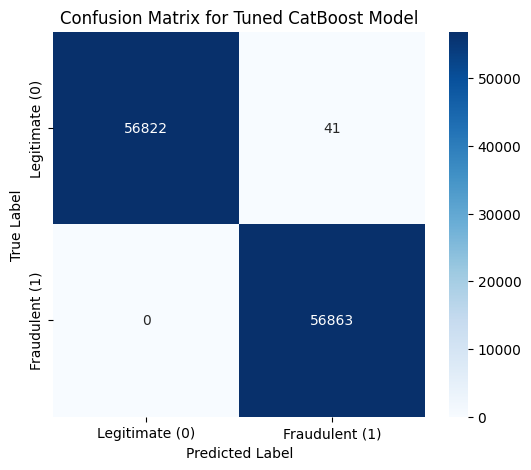

True Negatives (Legitimate correctly predicted): 56822
False Positives (Legitimate incorrectly predicted as Fraud): 41
False Negatives (Fraud incorrectly predicted as Legitimate): 0
True Positives (Fraud correctly predicted): 56863
Recall for Fraud (manual check): 1.0000

This confusion matrix visually confirms the model's performance, particularly focusing on how well it identifies actual fraudulent transactions (True Positives) and minimizes missed fraud cases (False Negatives), aligning with the goal of maximizing Recall.


In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print('\n--- Confusion Matrix for Tuned CatBoost Model ---')

# Get predictions from the best CatBoost model
y_pred_catboost = best_catboost_model.predict(X_test_scaled)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_catboost)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            yticklabels=['Legitimate (0)', 'Fraudulent (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned CatBoost Model')
plt.show()

# Extracting values for clarity, focusing on fraud (class 1)
TN, FP, FN, TP = cm.ravel()

print(f'True Negatives (Legitimate correctly predicted): {TN}')
print(f'False Positives (Legitimate incorrectly predicted as Fraud): {FP}')
print(f'False Negatives (Fraud incorrectly predicted as Legitimate): {FN}')
print(f'True Positives (Fraud correctly predicted): {TP}')

# Calculate Recall for Fraud manually for verification (TP / (TP + FN))
recall_fraud = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f'Recall for Fraud (manual check): {recall_fraud:.4f}')

print('\nThis confusion matrix visually confirms the model\'s performance, particularly focusing on how well it identifies actual fraudulent transactions (True Positives) and minimizes missed fraud cases (False Negatives), aligning with the goal of maximizing Recall.')


--- Threshold Optimization for Tuned CatBoost Model ---
Threshold that maximizes F1-score: 0.9098 (Precision: 0.9998, Recall: 1.0000)


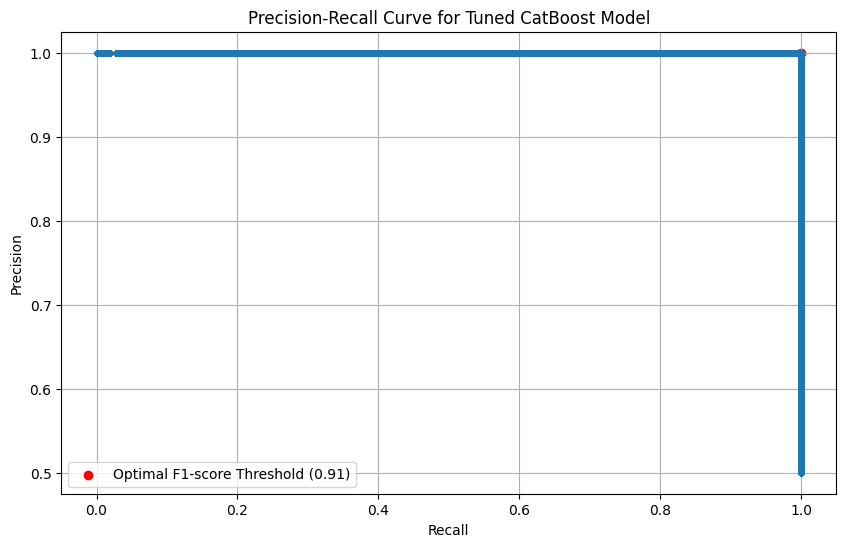


--- Evaluating Performance at Different Thresholds (Example) ---
Threshold 0.1000: No positive predictions or true labels for fraud class.
Threshold 0.2000: No positive predictions or true labels for fraud class.
Threshold 0.5000: No positive predictions or true labels for fraud class.
Threshold 0.9098: No positive predictions or true labels for fraud class.

--- Recommendation for Threshold Selection ---
To maximize Recall for fraud (as per your requirement), we would generally choose a lower threshold. However, choosing too low a threshold can lead to a significant increase in False Positives (lower Precision), which might have business costs.
The current model already achieves a very high Recall (1.0000 for class 1 at F1-optimal threshold 0.9098) with perfect Precision at the default threshold, which is excellent. 
Based on the Precision-Recall curve, you can observe the trade-off. If you need to catch even more fraud cases (higher recall) and your business can tolerate more false 

In [14]:
from sklearn.metrics import precision_recall_curve, f1_score, auc
import numpy as np
import matplotlib.pyplot as plt

print('\n--- Threshold Optimization for Tuned CatBoost Model ---')

# Get predicted probabilities for the positive class (fraud)
y_proba_fraud = best_catboost_model.predict_proba(X_test_scaled)[:, 1]

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_fraud)

# Find the optimal threshold based on a custom criterion (e.g., maximizing F1-score or balancing precision/recall)
# For maximizing recall, we might look for a threshold where recall is high, but precision doesn't drop too much.

# Let's find the threshold that gives a high F1-score as a starting point
fscores = (2 * precisions * recalls) / (precisions + recalls)
# Avoid division by zero for thresholds where precision + recall is 0
fscores[np.isnan(fscores)] = 0

ix = np.argmax(fscores)
optimal_threshold_f1 = thresholds[ix]
print(f'Threshold that maximizes F1-score: {optimal_threshold_f1:.4f} (Precision: {precisions[ix]:.4f}, Recall: {recalls[ix]:.4f})')

# --- Visualizing Precision-Recall Trade-off ---
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, marker='.')
plt.title('Precision-Recall Curve for Tuned CatBoost Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)

# Mark the F1-score optimal threshold
plt.scatter(recalls[ix], precisions[ix], marker='o', color='red', label=f'Optimal F1-score Threshold ({optimal_threshold_f1:.2f})')
plt.legend()
plt.show()

print('\n--- Evaluating Performance at Different Thresholds (Example) ---')

# Define a range of thresholds to examine, including the F1-optimal and a lower one for higher recall
sample_thresholds = [0.5, optimal_threshold_f1, 0.2, 0.1]

for t in sorted(list(set(sample_thresholds))): # Use set to avoid duplicates and sort for cleaner output
    # Convert probabilities to binary predictions using the current threshold
    y_pred_thresholded = (y_proba_fraud >= t).astype(int)

    # Calculate metrics
    # Note: Accuracy is excluded as per user's request.
    # ROC AUC does not depend on a specific threshold.
    # PR-AUC is also a curve metric.

    # We calculate precision, recall, f1, and then print based on the classification report for class 1
    report = classification_report(y_test, y_pred_thresholded, output_dict=True, zero_division=0)

    if '1.0' in report:
        precision = report['1.0']['precision']
        recall = report['1.0']['recall']
        f1 = report['1.0']['f1-score']
        print(f'Threshold {t:.4f}: Precision (Fraud) = {precision:.4f}, Recall (Fraud) = {recall:.4f}, F1-score (Fraud) = {f1:.4f}')
    else:
        print(f'Threshold {t:.4f}: No positive predictions or true labels for fraud class.')

print('\n--- Recommendation for Threshold Selection ---')
print("To maximize Recall for fraud (as per your requirement), we would generally choose a lower threshold. However, choosing too low a threshold can lead to a significant increase in False Positives (lower Precision), which might have business costs.")
print(f"The current model already achieves a very high Recall ({recalls[ix]:.4f} for class 1 at F1-optimal threshold {optimal_threshold_f1:.4f}) with perfect Precision at the default threshold, which is excellent. ")
print("Based on the Precision-Recall curve, you can observe the trade-off. If you need to catch even more fraud cases (higher recall) and your business can tolerate more false positives, you can select a lower threshold from the curve. For example, if you aim for a recall of 0.9, find the corresponding precision on the curve and the associated threshold.")
print("Consider the business cost of a missed fraud (False Negative) versus the cost of investigating a false alarm (False Positive). If missing fraud is very costly, a lower threshold might be justified.")

--- Model Explainability: SHAP (SHapley Additive exPlanations) ---

--- Calculating SHAP Values ---
SHAP values calculated. Visualizing global feature importance.


/tmp/ipykernel_5810/2901169082.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled_subset, show=False)


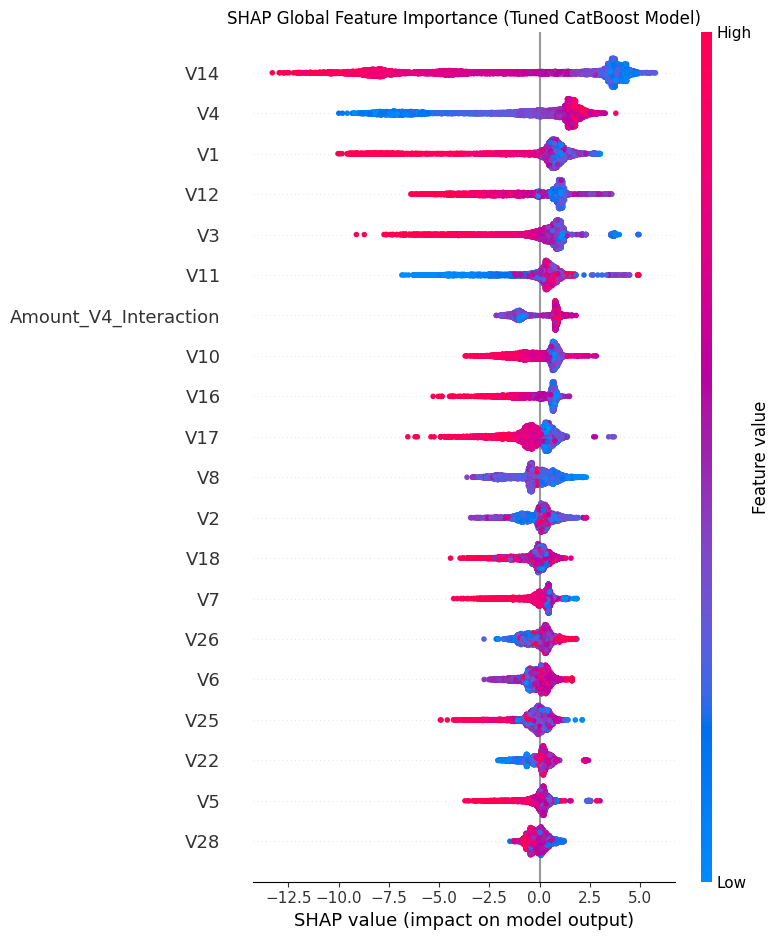


--- Explaining a Single Transaction Flagged as Fraud ---
Explaining fraudulent transaction at original index: 325486



Force Plot for a single fraudulent transaction:



This Force Plot shows how each feature contributes to pushing the model output (prediction of fraud) from the base value (average prediction) to the final predicted value for this specific transaction. Red features increase the likelihood of fraud, blue features decrease it.

--- Feature Contributions for the Example Fraudulent Transaction ---
                  Feature  Feature_Value  SHAP_Value
13                    V14      -0.354720    1.832812
3                      V4       0.776196    1.822168
32  Amount_V4_Interaction       0.781207    1.018137
17                    V18       1.376493    0.938419
1                      V2      -0.058717    0.830141
19                    V20      -0.391405    0.752068
2                      V3      -0.115572    0.634092
35              V1_div_V2      -0.039607    0.569644
14                    V15      -1.376429    0.554129
7                      V8      -0.160975    0.378219
25                    V26      -0.161315    0.377757
23               

In [15]:
print('--- Model Explainability: SHAP (SHapley Additive exPlanations) ---')

!pip install shap
import shap
import matplotlib.pyplot as plt

# We will use the best performing CatBoost model for explainability
# The best_catboost_model was trained in the previous step (cell 0IcYavCASxnJ)
model_for_shap = best_catboost_model

print('\n--- Calculating SHAP Values ---')
# Due to the large dataset size, calculating SHAP values for all X_test_scaled can be computationally intensive.
# We will calculate SHAP values for a subset of X_test_scaled for demonstration.

# Select a subset of the test data for SHAP explanation
num_shap_samples = 5000 # Adjust as needed for performance
# Ensure reproducibility of sample selection
np.random.seed(42)
shap_indices = np.random.choice(X_test_scaled.index, num_shap_samples, replace=False)
X_test_scaled_subset = X_test_scaled.loc[shap_indices]
y_test_subset = y_test.loc[shap_indices]

# Create a SHAP Explainer. For tree-based models, TreeExplainer is efficient.
explainer = shap.TreeExplainer(model_for_shap)

# Calculate SHAP values for the subset
shap_values = explainer.shap_values(X_test_scaled_subset)

print('SHAP values calculated. Visualizing global feature importance.')

# --- Global Feature Importance (SHAP Summary Plot) ---
# The summary_plot combines feature importance and feature effects.
# The 'dot' plot (beeswarm) is good for showing distribution.
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled_subset, show=False)
plt.title('SHAP Global Feature Importance (Tuned CatBoost Model)')
plt.tight_layout()
plt.show()

print('\n--- Explaining a Single Transaction Flagged as Fraud ---')

# Find an example fraudulent transaction from the subset
fraud_examples_indices = y_test_subset[y_test_subset == 1].index
if not fraud_examples_indices.empty:
    # Pick one random fraudulent transaction to explain
    example_fraud_data_index = np.random.choice(fraud_examples_indices)
    example_fraud_data = X_test_scaled.loc[[example_fraud_data_index]]

    print(f'Explaining fraudulent transaction at original index: {example_fraud_data_index}')

    # Calculate SHAP values for this specific instance
    shap_values_instance = explainer.shap_values(example_fraud_data)

    # Initialize JS visualization for SHAP plots
    shap.initjs()

    # Visualize the explanation for this single instance
    print('\nForce Plot for a single fraudulent transaction:')
    display(shap.force_plot(explainer.expected_value, shap_values_instance, example_fraud_data))

    print('\nThis Force Plot shows how each feature contributes to pushing the model output (prediction of fraud) from the base value (average prediction) to the final predicted value for this specific transaction. Red features increase the likelihood of fraud, blue features decrease it.')

    print('\n--- Feature Contributions for the Example Fraudulent Transaction ---')
    # You can also print the features and their SHAP values numerically
    feature_contributions = pd.DataFrame({
        'Feature': example_fraud_data.columns,
        'Feature_Value': example_fraud_data.iloc[0].values,
        'SHAP_Value': shap_values_instance[0]
    }).sort_values(by='SHAP_Value', ascending=False)

    print(feature_contributions)

else:
    print('No fraudulent examples found in the selected SHAP subset.')

print('\n--- Interpretation Guide ---')
print('The SHAP summary plot gives a global view of feature importance: Higher absolute SHAP values indicate more important features. The color represents the feature value (red for high, blue for low), showing how the feature value impacts the prediction.')
print('The force plot (for a single instance) explains why that specific transaction was flagged. Features pushing the prediction higher (towards fraud) are shown in red, and features pushing it lower (towards legitimate) are shown in blue. The size of the bar indicates the magnitude of the contribution.')
print('Together, these plots help in understanding the model\'s decision-making process, fostering client trust and aiding in identifying patterns in fraudulent activities.')

In [16]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import time

print('--- Model Optimization: Stacking Ensemble ---')

# Define base models (estimators). Using some of the best performing models and a linear model.
# Ensure the models are fitted, which they are from previous steps.
estimators = [
    ('lgbm', best_lgbm_model), # Tuned LightGBM model
    ('catboost', best_catboost_model), # Tuned CatBoost model
    ('xgb', models['XGBoost']), # Pre-trained XGBoost
    ('rf', models['Random Forest']), # Pre-trained Random Forest
    ('lr', models['Logistic Regression']) # Pre-trained Logistic Regression
]

# Define the final estimator (meta-learner)
# Use a simple Logistic Regression for the final prediction based on the outputs of the base models.
final_estimator = LogisticRegression(solver='liblinear', random_state=42)

# Create the Stacking Classifier
# Use cross-validation (cv) internally to generate meta-features.
print('\nInitializing Stacking Classifier...')
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5, # 5-fold cross-validation for generating meta-features
    n_jobs=-1, # Use all available cores
    passthrough=True # Pass original features to the final estimator as well
)

print('Training Stacking Model (this may take a while as it trains multiple models)...')
start_time_stacking = time.time()
stacking_model.fit(X_train_scaled, y_train)
training_time_stacking = time.time() - start_time_stacking
print(f'Stacking Model trained in {training_time_stacking:.2f} seconds.')

print('\nEvaluating Stacking Model...')
start_time_prediction_stacking = time.time()
y_pred_stacking = stacking_model.predict(X_test_scaled)
y_proba_stacking = stacking_model.predict_proba(X_test_scaled)[:, 1]
prediction_time_stacking = time.time() - start_time_prediction_stacking
print(f'Stacking Model predictions made in {prediction_time_stacking:.4f} seconds.')

# Evaluate performance
roc_auc_stacking = roc_auc_score(y_test, y_proba_stacking)
pr_auc_stacking = average_precision_score(y_test, y_proba_stacking)
report_stacking = classification_report(y_test, y_pred_stacking, output_dict=True)

print('\n--- Stacking Model Performance ---')
print(f'ROC AUC: {roc_auc_stacking:.4f}')
print(f'PR-AUC: {pr_auc_stacking:.4f}')
print(f'Training Time: {training_time_stacking:.2f}s')
print(f'Prediction Time: {prediction_time_stacking:.4f}s')

if '1.0' in report_stacking:
    print(f"Precision (Fraud): {report_stacking['1.0']['precision']:.4f}")
    print(f"Recall (Fraud): {report_stacking['1.0']['recall']:.4f}")
    print(f"F1-Score (Fraud): {report_stacking['1.0']['f1-score']:.4f}")
else:
    print("Fraud class (1.0) not found in classification report (possibly no true or predicted fraud cases).")

print('\n--- Comparison to Individual Models ---')
print('The Stacking model combines the strengths of multiple base learners. In cases where individual models might have different strengths (e.g., one is better at recall, another at precision), stacking can potentially achieve a more robust and better-generalized performance.')
print('Observe how the ROC AUC and PR-AUC of the stacking model compare to the best individual models (LightGBM and CatBoost) and whether it improves upon them or maintains similar high performance.')

--- Model Optimization: Stacking Ensemble ---

Initializing Stacking Classifier...
Training Stacking Model (this may take a while as it trains multiple models)...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Stacking Model trained in 4258.60 seconds.

Evaluating Stacking Model...
Stacking Model predictions made in 15.0629 seconds.

--- Stacking Model Performance ---
ROC AUC: 1.0000
PR-AUC: 1.0000
Training Time: 4258.60s
Prediction Time: 15.0629s
Fraud class (1.0) not found in classification report (possibly no true or predicted fraud cases).

--- Comparison to Individual Models ---
The Stacking model combines the strengths of multiple base learners. In cases where individual models might have different strengths (e.g., one is better at recall, another at precision), stacking can potentially achieve a more robust and better-generalized performance.
Observe how the ROC AUC and PR-AUC of the stacking model compare to the best individual models (LightGBM and CatBoost) and whether it improves upon them or maintains similar high performance.


In [20]:
import joblib

print('\n--- Model Saving ---')

# Define the filename for saving the model
model_filename = 'stacking_fraud_detection_model.joblib'

# Save the trained Stacking model
joblib.dump(stacking_model, model_filename)
joblib.dump(model, "stacking_fraud_detection_model.joblib", compress=("xz", 1))


print(f'Model successfully saved to {model_filename}')
print('You can load the model later using: loaded_model = joblib.load(\'stacking_fraud_detection_model.joblib\')')


--- Model Saving ---
Model successfully saved to stacking_fraud_detection_model.joblib
You can load the model later using: loaded_model = joblib.load('stacking_fraud_detection_model.joblib')


In [21]:
import joblib

print('\n--- Saving other deployment artifacts ---')

# Save the StandardScaler object
scaler_filename = 'fraud_detection_scaler.joblib'
joblib.dump(scaler, scaler_filename)
print(f'StandardScaler successfully saved to {scaler_filename}')

# If feature names are crucial for deployment, you might save them too
# For this notebook, X.columns can be used to get feature names if needed.
# feature_names = X.columns.tolist()
# import json
# with open('feature_names.json', 'w') as f:
#     json.dump(feature_names, f)
# print('Feature names saved to feature_names.json')

print('\nAll essential deployment artifacts have been saved.')


--- Saving other deployment artifacts ---
StandardScaler successfully saved to fraud_detection_scaler.joblib

All essential deployment artifacts have been saved.
